In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

from ortools.constraint_solver import pywrapcp, routing_enums_pb2

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], format="%H:%M:%S", errors="coerce")
df["Type_of_vehicle"] = df["Type_of_vehicle"].str.strip()
df = df[
    (df["Restaurant_latitude"] != 0.0) &
    (df["Restaurant_longitude"] != 0.0) &
    (df["Delivery_location_latitude"] != 0.0) &
    (df["Delivery_location_longitude"] != 0.0) &
    (df["Type_of_vehicle"].isin(["scooter","motorcycle"])) 
]
df.dropna(inplace=True)

C:\Users\upeks\AppData\Local\Temp\ipykernel_2588\3398115205.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order_Date"] = pd.to_datetime(df["Order_Date"])


In [4]:
temp_df = df[["Restaurant_latitude", "Restaurant_longitude"]]
temp_df = temp_df.groupby(by=["Restaurant_latitude", "Restaurant_longitude"]).size().reset_index(name="Count")
temp_df.sort_values(by="Count", ascending=False, inplace=True)
temp_df = temp_df[
    (temp_df["Restaurant_latitude"].apply(lambda x: 26.0 <= x <= 27.0)) &
    (temp_df["Restaurant_longitude"].apply(lambda x: 75.0 <= x <= 76.0))
]

In [5]:
start_time = pd.to_datetime("00:01:01").time()
end_time = pd.to_datetime("23:59:59").time()
start_date = pd.to_datetime("2022-03-01")
end_date = pd.to_datetime("2022-04-06")
full_date_range = pd.date_range(start=start_date, end=end_date)
restaurant_latitude = temp_df["Restaurant_latitude"].mean()
restaurant_longitude = temp_df["Restaurant_longitude"].mean()

In [6]:
main_df = df[
    (df["Restaurant_latitude"].isin(temp_df["Restaurant_latitude"])) &
    (df["Restaurant_longitude"].isin(temp_df["Restaurant_longitude"])) &
    (df["Time_Orderd"].dt.time.between(start_time, end_time)) &
    (df["Order_Date"].between(start_date, end_date))
]

In [7]:
scaler1 = StandardScaler()
main_df[["Scaled_Customer_Latitude", "Scaled_Customer_Longitude"]] = scaler1.fit_transform(main_df[["Delivery_location_latitude", "Delivery_location_longitude"]])

C:\Users\upeks\AppData\Local\Temp\ipykernel_2588\15163636.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df[["Scaled_Customer_Latitude", "Scaled_Customer_Longitude"]] = scaler1.fit_transform(main_df[["Delivery_location_latitude", "Delivery_location_longitude"]])
C:\Users\upeks\AppData\Local\Temp\ipykernel_2588\15163636.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df[["Scaled_Customer_Latitude", "Scaled_Customer_Longitude"]] = scaler1.fit_transform(main_df[["Delivery_location_latitude",

In [8]:
def find_best_k(data, max_k):
    silhouette_scores = []
    kmeans_labels = []
    for k in range(2, max_k+1):
        kmeans_optimal = KMeans(n_clusters=k)
        kmeans_optimal.fit(data)
        kmeans_labels.append((k, kmeans_optimal.labels_))
        silhouette_scores.append((k, silhouette_score(data, kmeans_optimal.labels_)))
    return silhouette_scores, kmeans_labels

In [9]:
silhouette_scores, kmeans_labels = find_best_k(main_df[["Scaled_Customer_Latitude", "Scaled_Customer_Longitude"]], 10)
best_k, best_score = max(silhouette_scores, key=lambda x: x[1])
best_labels = next(lbl for k, lbl in kmeans_labels if k == best_k)
main_df["K-Means Label"] = best_labels

c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  

C:\Users\upeks\AppData\Local\Temp\ipykernel_2588\3655206591.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


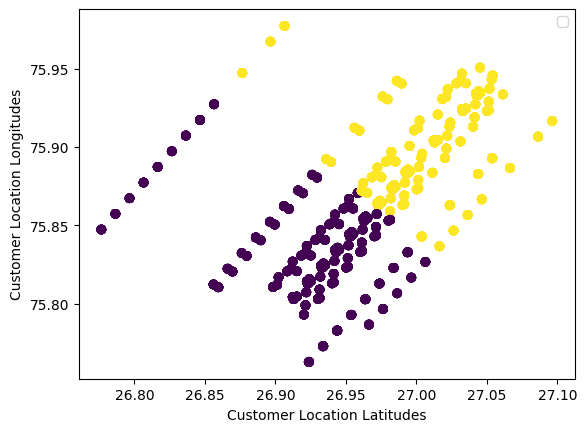

In [10]:
plt.scatter(x=main_df["Delivery_location_latitude"], y=main_df["Delivery_location_longitude"], c=main_df["K-Means Label"])
plt.xlabel("Customer Location Latitudes")
plt.ylabel("Customer Location Longitudes")
plt.legend()
plt.show()

In [11]:
cluster_df = main_df[main_df["K-Means Label"] == 1]
cluster_df = cluster_df.groupby(by="Order_Date").size().reset_index(name="Number of Deliveries")
cluster_df.sort_values(by="Order_Date", inplace=True)
cluster_df.set_index(keys="Order_Date", inplace=True)
cluster_df = cluster_df.reindex(labels=full_date_range, fill_value=0)
cluster_df.reset_index(inplace=True)
cluster_df.columns = ["Order_Date", "Number of Deliveries"]

In [12]:
data = cluster_df["Number of Deliveries"].to_numpy()

In [13]:
def create_sequences(data, sequence_length):
    sequences = []
    for i in range(len(data)-sequence_length):
        seq = data[i:i+sequence_length]
        lbl = data[i+sequence_length]
        sequences.append((seq, lbl))
    return sequences

In [14]:
sequences = create_sequences(data, 5)

In [15]:
X_seq = np.array([seq[0] for seq in sequences])
y_lbl = np.array([[lbl[1]] for lbl in sequences])

In [16]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_seq)
y_scaled = scaler_y.fit_transform(y_lbl)

In [17]:
X = torch.tensor(X_scaled, dtype=torch.float32)
y = torch.tensor(y_scaled, dtype=torch.float32)

In [18]:
dataset = TensorDataset(X.unsqueeze(-1), y.unsqueeze(-1))
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [19]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [20]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        output = self.fc(out[:, -1, :])
        return output

In [21]:
model = LSTMModel(1, 4, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    verbose=True
)
epochs = 200

c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [22]:
early_stopping_patience = 5
min_val_loss = float('inf')
patience_counter = 0

In [23]:
def training_loop():
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    return train_loss/len(train_loader)

In [24]:
def validating_loop():
    model.eval()
    val_loss = 0.0
    with torch.no_grad():   
        for X_batch, y_batch in val_loader:
            output = model(X_batch)
            loss = criterion(output, y_batch)
            val_loss += loss.item()
    return val_loss/len(val_loader)

In [25]:
for epoch in range(epochs):
    train_loss = training_loop()
    val_loss = validating_loop()
    print(f"Epoch: {epoch+1} Train Loss: {train_loss} Validation Loss: {val_loss}")
    scheduler.step(val_loss)

    if val_loss < min_val_loss:
        min_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print("Early Stopping Triggered")
            break

model.load_state_dict(torch.load("best_model.pth"))
model.eval()
print("Training Completed. Best Model Loaded")

Epoch: 1 Train Loss: 0.1838940680027008 Validation Loss: 0.18129995465278625
Epoch: 2 Train Loss: 0.17896300554275513 Validation Loss: 0.17510052025318146
Epoch: 3 Train Loss: 0.17619042098522186 Validation Loss: 0.1709587275981903
Epoch: 4 Train Loss: 0.17515648901462555 Validation Loss: 0.16850358247756958
Epoch: 5 Train Loss: 0.1753244400024414 Validation Loss: 0.1672816127538681
Epoch: 6 Train Loss: 0.1760290116071701 Validation Loss: 0.16679193079471588
Epoch: 7 Train Loss: 0.17664942145347595 Validation Loss: 0.16665656864643097
Epoch: 8 Train Loss: 0.17688575387001038 Validation Loss: 0.16670691967010498
Epoch: 9 Train Loss: 0.17674624919891357 Validation Loss: 0.1669083833694458
Epoch: 10 Train Loss: 0.176374614238739 Validation Loss: 0.16727134585380554
Epoch: 11 Train Loss: 0.1759295016527176 Validation Loss: 0.16780135035514832
Epoch: 12 Train Loss: 0.17553256452083588 Validation Loss: 0.16812777519226074
Early Stopping Triggered
Training Completed. Best Model Loaded


c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([25, 1, 1])) that is different to the input size (torch.Size([25, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([7, 1, 1])) that is different to the input size (torch.Size([7, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\upeks\AppData\Local\Temp\ipykernel_2588\3780319371.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to con

In [26]:
for param_group in optimizer.param_groups:
    print(f"Current Learning Rate: {param_group['lr']}")

Current Learning Rate: 0.005


In [27]:
# Collect predictions and actual values
predictions = []
actuals = []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        preds = model(X_batch)
        predictions.append(preds)
        actuals.append(y_batch)

# Convert to Tensors -> Numpy for plotting
predictions = scaler_y.inverse_transform(np.vstack(predictions))
actuals = scaler_y.inverse_transform(np.vstack(actuals))

# Plot predictions vs. actuals
plt.plot(predictions, label="Predictions", marker='o')
plt.plot(actuals, label="Actuals", marker='x')
plt.legend()

plt.show()

ValueError: Found array with dim 3. None expected <= 2.